# Porter et al. (2017) ISRF — FEUPY analysis and Naima validation

This notebook evaluates the spatially interpolated GALPROP R12 interstellar radiation field (ISRF), verifies its spectral components and integrated energy density, fits diluted blackbodies using non-negative least squares (NNLS), and **compares inverse-Compton (IC) emission in Naima** for tabulated and thermal seed-photon fields.

**Conventions:** the GALPROP SED is $S(\epsilon)=\epsilon^2\,dn/d\epsilon$ in eV cm$^{-3}$, and $u=\int S(\epsilon)\,d\ln\epsilon$. The CMB is added separately to both Naima models. The blackbody fit is an approximation, not an exact decomposition of the physical GALPROP components.

**Prerequisites:** `feupy`, `astropy`, `numpy`, `scipy`, `matplotlib`, and `naima`. Set `$FEUPY_DATA` before starting Jupyter. The examples use the updated `Porter2017ISRF` implementation supporting `fit_blackbody_components(method="nnls")` and `to_naima_blackbodies()`.

## 1. Imports and configuration

In [6]:
# Licensed under a 3-clause BSD style license - see LICENSE.rst
import os
from time import perf_counter

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord

import feupy
from feupy.isrf import Porter2017ISRF
from feupy.isrf.utils import blackbody_sed, integrate_isrf_sed

SED_UNIT = u.eV / u.cm**3
PLOT_FLOOR = 1e-12  # Display only; do not modify data used for fitting.

print("FEUPY version:", feupy.__version__)
print("FEUPY_DATA:", os.environ.get("FEUPY_DATA", "NOT SET"))

FEUPY version: 0.1.0
FEUPY_DATA: /home/phoenix/Coding/GitHub/feupy-data/feupy-datasets/1.0


In [7]:
isrf = Porter2017ISRF(model="R12", component="Total")
print("Model:", isrf.model)
print("Model directory:", isrf.model_dir)
print("Components:", isrf.available_components)
print("Photon-energy bins:", isrf.energy.size)

Model: R12
Model directory: /home/phoenix/Coding/GitHub/feupy-data/feupy-datasets/1.0/isrf/porter2017/Porter_etal_ApJ_846_67_2017_SEDonly/R12
Components: ('Total', 'Direct', 'Scattered', 'Transient', 'Thermal')
Photon-energy bins: 128


## 2. Galactic position and original GALPROP spectrum

The reference position is $(l,b,d)=(17.8^\circ,-0.7^\circ,4\,\mathrm{kpc})$.

Position: <SkyCoord (Galactic): (l, b, distance) in (deg, deg, kpc)
    (17.8, -0.7, 4.)>
Maximum SED: 1.0573928780928379 eV / cm3
Integrated energy density: 3.909067053838413 eV / cm3


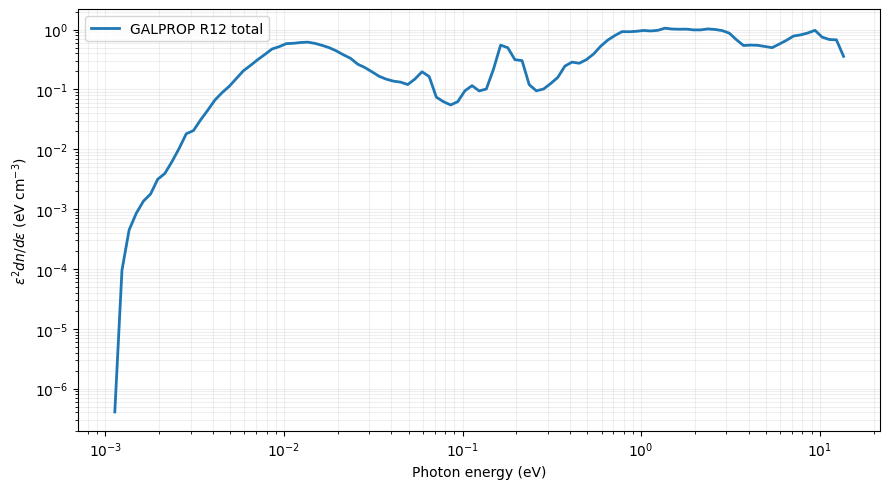

In [8]:
position = SkyCoord(l=17.8*u.deg, b=-0.7*u.deg, distance=4.0*u.kpc, frame="galactic")
energy, sed = isrf.spectrum(position, component="Total")
e_values = energy.to_value(u.eV)
s_values = sed.to_value(SED_UNIT)
print("Position:", position)
print("Maximum SED:", sed.max())
print("Integrated energy density:", isrf.energy_density(position))

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(e_values, np.where(s_values > PLOT_FLOOR, s_values, np.nan), lw=2, label="GALPROP R12 total")
ax.set(xlabel="Photon energy (eV)", ylabel=r"$\epsilon^2 dn/d\epsilon$ (eV cm$^{-3}$)")
ax.grid(alpha=0.2, which="both")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Physical GALPROP components

`Direct`, `Scattered`, `Transient`, and `Thermal` are physical GALPROP outputs; they are **not** identical to the fitted FIR/NIR/VIS/UV thermal fields.

Direct    : 2.246421 eV / cm3
Scattered : 0.505275 eV / cm3
Transient : 0.604571 eV / cm3
Thermal   : 0.552800 eV / cm3
Max absolute component-sum residual: 2.220446049250313e-16 eV/cm3


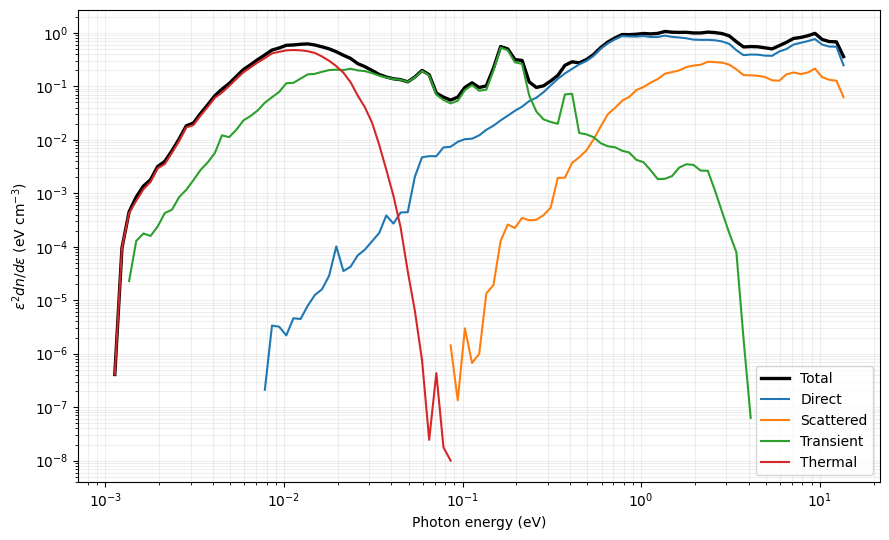

In [9]:
components = ("Direct", "Scattered", "Transient", "Thermal")
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(e_values, np.where(s_values > PLOT_FLOOR, s_values, np.nan), color="black", lw=2.4, label="Total")
component_sum = np.zeros_like(s_values)
for component in components:
    _, spectrum = isrf.spectrum(position, component=component)
    values = spectrum.to_value(SED_UNIT)
    component_sum += values
    ax.loglog(e_values, np.where(values > PLOT_FLOOR, values, np.nan), label=component)
    print(f"{component:10s}: {isrf.energy_density(position, component=component):.6f}")
print("Max absolute component-sum residual:", np.max(np.abs(component_sum - s_values)), "eV/cm3")
ax.set(xlabel="Photon energy (eV)", ylabel=r"$\epsilon^2 dn/d\epsilon$ (eV cm$^{-3}$)")
ax.grid(alpha=0.2, which="both")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Reference regression check

This check uses the R12 data and reference coordinate convention previously validated for the FEUPY implementation. It is data-dependent, not a universal ISRF value.

In [10]:
reference_density = 3.909067053838413 * SED_UNIT
measured_density = isrf.energy_density(position)
print("Reference:", reference_density)
print("Measured: ", measured_density)
print("Relative difference:", (measured_density/reference_density - 1).to_value(u.one))
np.testing.assert_allclose(measured_density.to_value(SED_UNIT), reference_density.to_value(SED_UNIT), rtol=1e-5)

Reference: 3.909067053838413 eV / cm3
Measured:  3.909067053838413 eV / cm3
Relative difference: 0.0


## 5. Thermal approximation: reproduce the original notebook

The original three-component linear fit used **40, 500, and 3500 K**. The extended four-component fit adds a **20,000 K UV** field. All temperatures are fixed; NNLS fits only nonnegative bolometric energy densities. The 1% threshold selects fit bins.

In [11]:
TEMPERATURES_3BB = {"FIR": 40*u.K, "NIR": 500*u.K, "VIS": 3500*u.K}
TEMPERATURES_4BB = {**TEMPERATURES_3BB, "UV": 20000*u.K}

fit_3bb = isrf.fit_blackbody_components(position, temperatures=TEMPERATURES_3BB, method="nnls", threshold=0.01)
fit_4bb = isrf.fit_blackbody_components(position, temperatures=TEMPERATURES_4BB, method="nnls", threshold=0.01)

for label, fit in (("3BB", fit_3bb), ("4BB", fit_4bb)):
    print(f"\n{label} | method={fit['method']} | success={fit['success']}")
    for name, density in fit["energy_densities"].items():
        print(f"  {name:4s} ({fit['temperatures'][name]:>8}): {density:.4f}")
    print("  GALPROP integrated: ", fit["reference_integrated_density"])
    print("  BB integrated:      ", fit["fitted_integrated_density"])
    print("  BB bolometric sum:  ", fit["bolometric_density"])
    print(f"  Integrated difference: {fit['relative_integrated_difference']:+.2%}")
    print(f"  RMS log residual:     {fit['rms_log_residual']:.4f} dex")

assert fit_3bb["success"] and fit_4bb["success"]
np.testing.assert_allclose(
    [fit_3bb["energy_densities"][name].to_value(SED_UNIT) for name in TEMPERATURES_3BB],
    [0.8289, 0.2956, 1.6087], atol=0.003,
)
np.testing.assert_allclose(
    [fit_4bb["energy_densities"][name].to_value(SED_UNIT) for name in TEMPERATURES_4BB],
    [0.8288, 0.3019, 1.4914, 1.2304], atol=0.003,
)


3BB | method=nnls | success=True
  FIR  (    40.0 K): 0.8289 eV / cm3
  NIR  (   500.0 K): 0.2956 eV / cm3
  VIS  (  3500.0 K): 1.6087 eV / cm3
  GALPROP integrated:  3.909067053838413 eV / cm3
  BB integrated:       2.733208826375778 eV / cm3
  BB bolometric sum:   2.7332103196115805 eV / cm3
  Integrated difference: -30.08%
  RMS log residual:     2.8484 dex

4BB | method=nnls | success=True
  FIR  (    40.0 K): 0.8288 eV / cm3
  NIR  (   500.0 K): 0.3019 eV / cm3
  VIS  (  3500.0 K): 1.4914 eV / cm3
  UV   ( 20000.0 K): 1.2304 eV / cm3
  GALPROP integrated:  3.909067053838413 eV / cm3
  BB integrated:       3.7997170637775395 eV / cm3
  BB bolometric sum:   3.8524401801800257 eV / cm3
  Integrated difference: -2.80%
  RMS log residual:     0.2222 dex


## 6. Validate the blackbody approximation

The lower panel shows $S_{\mathrm{BB}}/S_{\mathrm{GALPROP}}$ only where the original SED exceeds the fitting threshold. A small integrated error does not guarantee small local spectral errors.

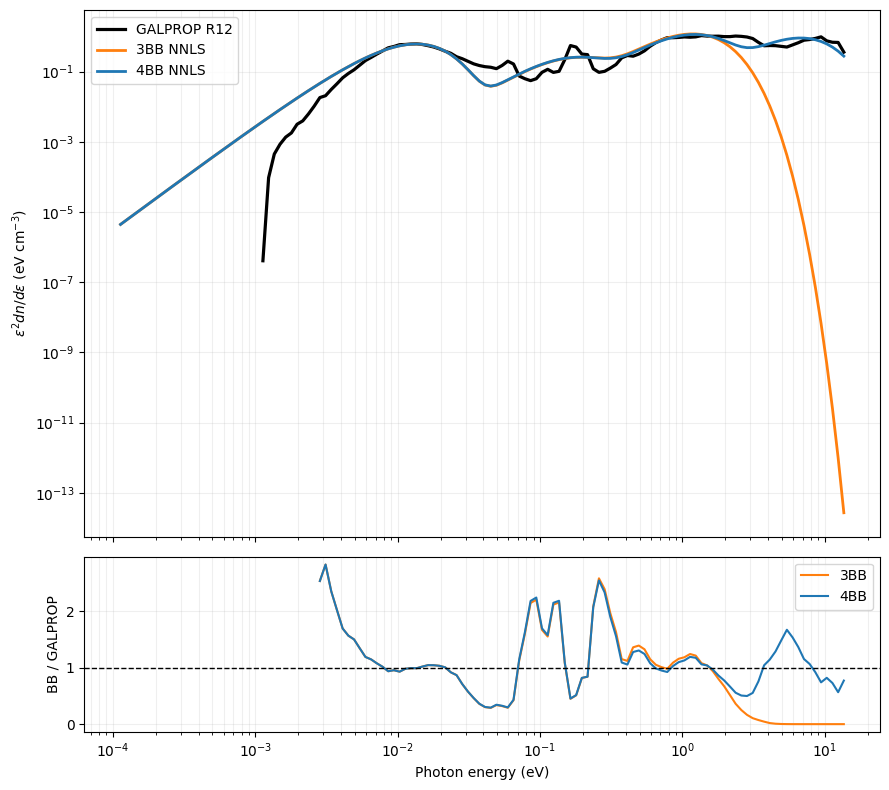

In [12]:
fig, (ax, axr) = plt.subplots(2, 1, figsize=(9, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax.loglog(e_values, np.where(s_values > PLOT_FLOOR, s_values, np.nan), color="black", lw=2.3, label="GALPROP R12")
for label, fit, color in (("3BB", fit_3bb, "tab:orange"), ("4BB", fit_4bb, "tab:blue")):
    ax.loglog(e_values, fit["fit_sed"].to_value(SED_UNIT), color=color, lw=2, label=f"{label} NNLS")
    valid = fit["mask"] & (s_values > 0)
    axr.semilogx(e_values[valid], (fit["fit_sed"].to_value(SED_UNIT)/s_values)[valid], color=color, label=label)
ax.set_ylabel(r"$\epsilon^2 dn/d\epsilon$ (eV cm$^{-3}$)")
ax.legend()
ax.grid(alpha=0.2, which="both")
axr.axhline(1, color="black", ls="--", lw=1)
axr.set(xlabel="Photon energy (eV)", ylabel="BB / GALPROP")
axr.grid(alpha=0.2, which="both")
axr.legend()
plt.tight_layout()
plt.show()

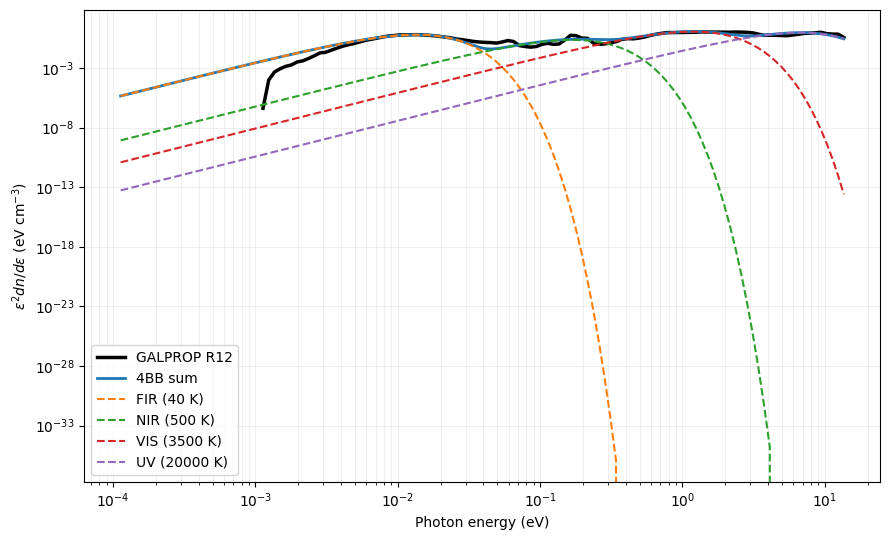

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(e_values, np.where(s_values > PLOT_FLOOR, s_values, np.nan), color="black", lw=2.5, label="GALPROP R12")
ax.loglog(e_values, fit_4bb["fit_sed"].to_value(SED_UNIT), lw=2, label="4BB sum")
for name, spectrum in fit_4bb["components"].items():
    ax.loglog(e_values, spectrum.to_value(SED_UNIT), ls="--", label=f"{name} ({fit_4bb['temperatures'][name]:.0f})")
ax.set(xlabel="Photon energy (eV)", ylabel=r"$\epsilon^2 dn/d\epsilon$ (eV cm$^{-3}$)")
ax.grid(alpha=0.2, which="both")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Alternative objectives (optional)

NNLS minimizes linear SED residuals under nonnegative normalizations. Logarithmic and relative objectives emphasize different regions. These are diagnostics, not interchangeable physical decompositions.

In [14]:
for method in ("nnls", "linear", "relative", "log"):
    result = isrf.fit_blackbody_components(position, temperatures=TEMPERATURES_4BB, method=method)
    print(f"{method:8s} success={result['success']!s:5s} "
          f"delta_u={result['relative_integrated_difference']:+.2%} "
          f"rms_log={result['rms_log_residual']:.4f} dex")

nnls     success=True  delta_u=-2.80% rms_log=0.2222 dex
linear   success=True  delta_u=-2.80% rms_log=0.2222 dex
relative success=True  delta_u=-21.29% rms_log=0.2729 dex
log      success=True  delta_u=-3.90% rms_log=0.2194 dex


## 8. Check blackbody normalization and photon density

The unit-normalized blackbody SED should integrate to approximately 1 eV cm$^{-3}$ over the finite GALPROP grid. `photon_density()` provides the original tabulated photon distribution for other applications.

In [15]:
for name, temp in TEMPERATURES_4BB.items():
    unit_bb = blackbody_sed(energy, temperature=temp, energy_density=1*SED_UNIT)
    print(f"{name:4s}: {integrate_isrf_sed(energy, unit_bb):.6f}")
photon_energy, photon_density = isrf.photon_density(position)
print("Photon density shape:", photon_density.shape)
print("Photon energy range:", photon_energy.min(), "to", photon_energy.max())

FIR : 0.999998 eV / cm3
NIR : 1.000000 eV / cm3
VIS : 1.000000 eV / cm3
UV  : 0.957151 eV / cm3
Photon density shape: (128,)
Photon energy range: 0.00011307493287993264 eV to 13.594597024829413 eV


## 9. Prepare Naima seed photon fields

`to_naima()` returns **one** tabulated field `[name, energy, SED]`; Naima expects a list of fields. `to_naima_blackbodies()` returns a list of thermal fields. The same CMB is added once to each model. If your FEUPY version differs, inspect the methods before running.

In [16]:
seed_galprop = [isrf.to_naima(position)] + ["CMB"]
seed_4bb = isrf.to_naima_blackbodies(position, method="nnls", include_cmb=True)

print("Tabulated field:", seed_galprop[0][0], "with", len(seed_galprop[0][1]), "bins")
print("Thermal fields:")
for field in seed_4bb:
    print(" ", field)
assert len(seed_galprop) == 2
assert len(seed_4bb) == 5
assert seed_galprop[-1] == seed_4bb[-1] == "CMB"

Tabulated field: Porter2017_R12_Total with 128 bins
Thermal fields:
  ['FIR', <Quantity 40. K>, <Quantity 0.82882663 eV / cm3>]
  ['NIR', <Quantity 500. K>, <Quantity 0.30185879 eV / cm3>]
  ['VIS', <Quantity 3500. K>, <Quantity 1.49135077 eV / cm3>]
  ['UV', <Quantity 20000. K>, <Quantity 1.23040399 eV / cm3>]
  CMB


## 10. Inverse-Compton comparison in Naima

The electron population and distance are identical for both calculations. The comparison includes CMB in both models. A Naima installation is required for the cells in this section. This is a validation experiment, not a fit to observed gamma-ray data.

In [17]:
import naima

electron_distribution = naima.models.ExponentialCutoffPowerLaw(
    amplitude=1e35 / u.eV,
    e_0=1*u.TeV,
    alpha=2.3,
    e_cutoff=100*u.TeV,
)

ic_galprop = naima.models.InverseCompton(electron_distribution, seed_photon_fields=seed_galprop)
ic_4bb = naima.models.InverseCompton(electron_distribution, seed_photon_fields=seed_4bb)

gamma_energy = np.geomspace(0.1, 1e5, 120)*u.GeV
DISTANCE = 1*u.kpc

start = perf_counter()
sed_ic_galprop = ic_galprop.sed(gamma_energy, distance=DISTANCE)
time_tabulated = perf_counter() - start
start = perf_counter()
sed_ic_4bb = ic_4bb.sed(gamma_energy, distance=DISTANCE)
time_thermal = perf_counter() - start

print(f"Tabulated evaluation: {time_tabulated:.3f} s")
print(f"4BB evaluation:       {time_thermal:.3f} s")
print("Note: single-call timings include setup/caching effects; benchmark repeated calls for performance claims.")

flux_tab = sed_ic_galprop.to_value(u.erg/(u.cm**2*u.s))
flux_bb = sed_ic_4bb.to_value(u.erg/(u.cm**2*u.s))
valid_ic = np.isfinite(flux_tab) & np.isfinite(flux_bb) & (flux_tab > 0)
ratio_ic = np.full(flux_tab.shape, np.nan)
ratio_ic[valid_ic] = flux_bb[valid_ic]/flux_tab[valid_ic]
print("Valid gamma-ray bins:", np.count_nonzero(valid_ic), "/", len(gamma_energy))

Tabulated evaluation: 1.979 s
4BB evaluation:       0.069 s
Note: single-call timings include setup/caching effects; benchmark repeated calls for performance claims.
Valid gamma-ray bins: 120 / 120


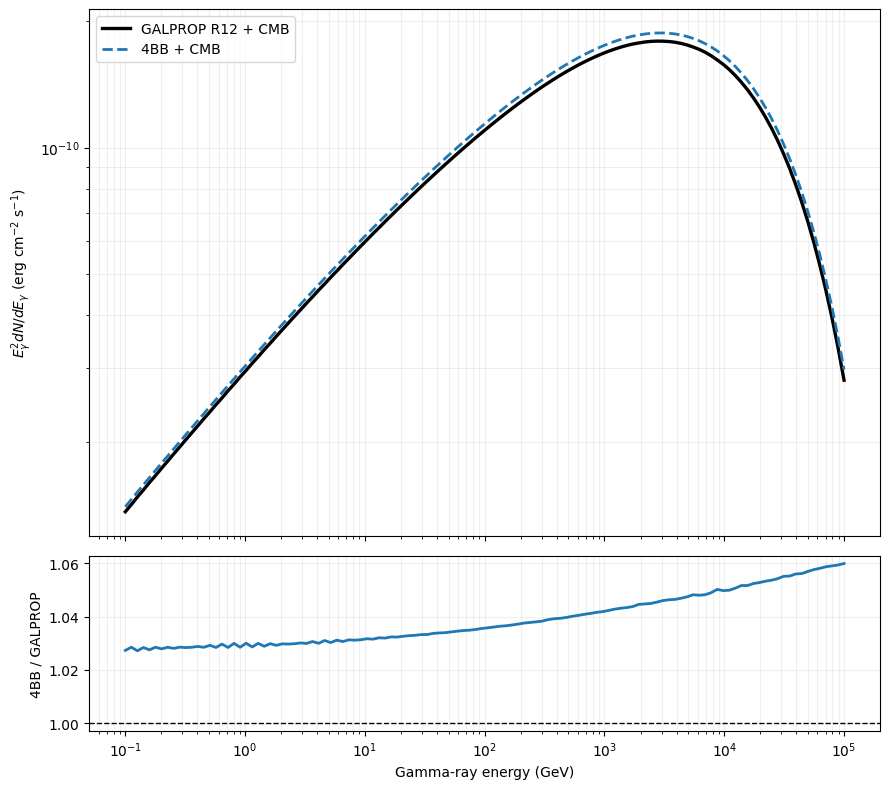

In [18]:
fig, (ax, axr) = plt.subplots(2, 1, figsize=(9, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
g_values = gamma_energy.to_value(u.GeV)
ax.loglog(g_values, np.where(flux_tab > 0, flux_tab, np.nan), color="black", lw=2.4, label="GALPROP R12 + CMB")
ax.loglog(g_values, np.where(flux_bb > 0, flux_bb, np.nan), color="tab:blue", ls="--", lw=2, label="4BB + CMB")
ax.set_ylabel(r"$E_\gamma^2 dN/dE_\gamma$ (erg cm$^{-2}$ s$^{-1}$)")
ax.legend()
ax.grid(alpha=0.2, which="both")
axr.semilogx(g_values[valid_ic], ratio_ic[valid_ic], color="tab:blue", lw=2)
axr.axhline(1, color="black", ls="--", lw=1)
axr.set(xlabel="Gamma-ray energy (GeV)", ylabel="4BB / GALPROP")
axr.grid(alpha=0.2, which="both")
plt.tight_layout()
plt.show()

## 11. Quantify IC deviations by energy band

The reported relative differences are evaluated only in bins with positive finite tabulated flux. Large errors in very faint tails may not be observationally relevant; inspect the SED plot alongside the summary.

In [19]:
for label, lo, hi in (("Fermi-LAT", 0.1, 100), ("VHE", 100, 1e5), ("Full range", 0.1, 1e5)):
    sel = valid_ic & (g_values >= lo) & (g_values <= hi)
    if not np.any(sel):
        print(f"{label}: no valid points")
        continue
    errors = np.abs(ratio_ic[sel] - 1)
    print(f"{label:12s}: N={sel.sum():3d}  median={100*np.median(errors):6.2f}%  "
          f"p90={100*np.percentile(errors,90):6.2f}%  max={100*np.max(errors):6.2f}%")

Fermi-LAT   : N= 60  median=  3.00%  p90=  3.40%  max=  3.55%
VHE         : N= 60  median=  4.62%  p90=  5.70%  max=  5.99%
Full range  : N=120  median=  3.57%  p90=  5.37%  max=  5.99%


## 12. Spatial dependence of the thermal approximation

Fixed temperatures are not guaranteed to describe every Galactic environment. Compare NNLS densities and integrated errors across a few positions; verify that each lies inside the interpolation domain.

In [20]:
test_positions = {
    "Reference": position,
    "Galactic center": SkyCoord(l=0*u.deg, b=0*u.deg, distance=8.5*u.kpc, frame="galactic"),
    "Anticenter": SkyCoord(l=180*u.deg, b=0*u.deg, distance=4*u.kpc, frame="galactic"),
    "High latitude": SkyCoord(l=30*u.deg, b=20*u.deg, distance=2*u.kpc, frame="galactic"),
}

for label, pos in test_positions.items():
    try:
        result = isrf.fit_blackbody_components(pos, temperatures=TEMPERATURES_4BB, method="nnls")
        density_str = ", ".join(f"{key}={value.to_value(SED_UNIT):.3f}" for key, value in result["energy_densities"].items())
        print(f"{label:16s}: delta_u={result['relative_integrated_difference']:+7.2%} | {density_str}")
    except (ValueError, OSError) as exc:
        print(f"{label:16s}: unavailable ({exc})")

Reference       : delta_u= -2.80% | FIR=0.829, NIR=0.302, VIS=1.491, UV=1.230
Galactic center : unavailable (Position outside GALPROP grid; choose a position within R=[0.1, 30.0] kpc and z=[-20.0, 20.0] kpc)
Anticenter      : delta_u= -3.61% | FIR=0.044, NIR=0.014, VIS=0.217, UV=0.181
High latitude   : delta_u= -3.08% | FIR=0.172, NIR=0.051, VIS=0.711, UV=0.387


## 13. Interpretation and next steps

- The **three-component** fit reproduces the original notebook; the **four-component** NNLS fit improves the integrated energy-density agreement at the reference position (previously measured as approximately **−2.80%**).
- The four fitted densities are **effective bolometric normalizations** and should not be confused with GALPROP `Direct`, `Scattered`, `Transient`, and `Thermal` physical components.
- The **IC SED ratio** is the relevant validation metric for Naima applications; agreement in integrated ISRF density alone is insufficient.
- Validate several electron spectra, Galactic positions, and gamma-ray bands before treating the 4BB approximation as a default scientific model.
- Keep the **tabulated** `to_naima()` pathway as the reference; use `to_naima_blackbodies()` when its accuracy and computational benefit have been demonstrated for the intended application.

The reference R12 data are provided separately from FEUPY via `$FEUPY_DATA`.